In [54]:
import os
import csv
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler


In [2]:
os.makedirs("./artifacts/figures", exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
df = pd.read_csv("S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"число наблюдений: {len(df)}")
print(f"диапазон дат: {df['date'].min()} - {df['date'].max()}")
print(f"число пропусков по колонкам:\n{df.isnull().sum()}")

число наблюдений: 4320
диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
число пропусков по колонкам:
date      0
target    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:30:00,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


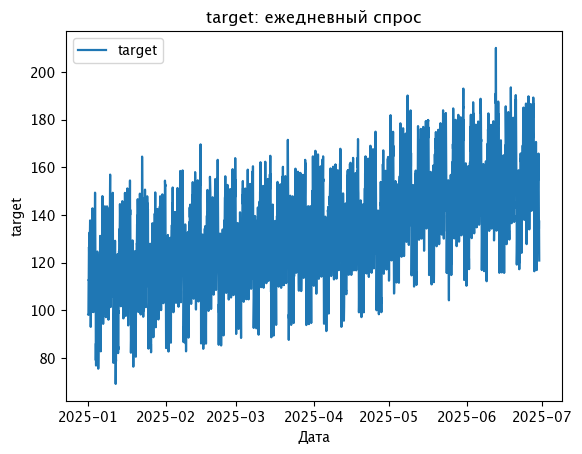

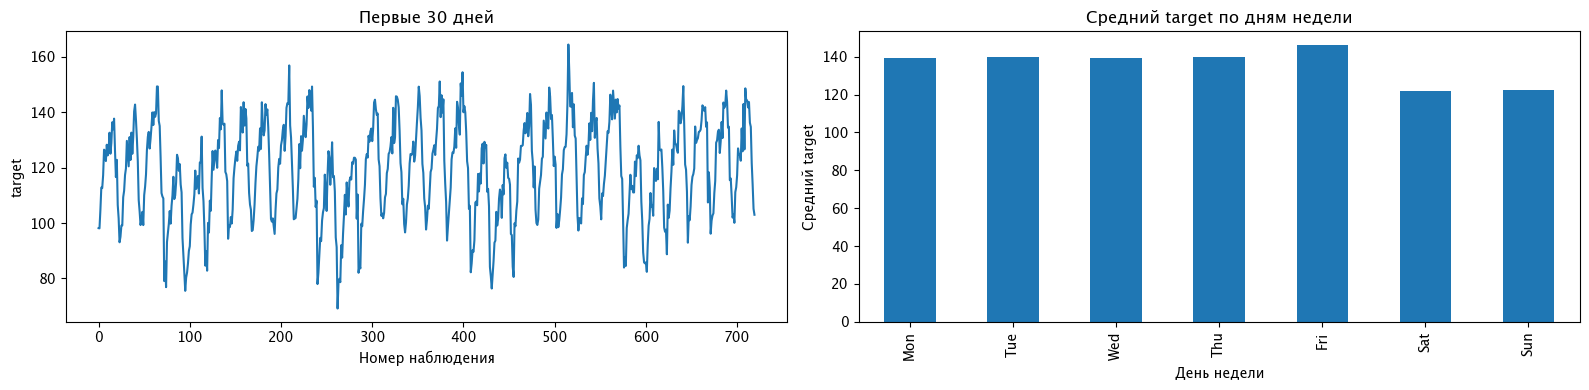

In [31]:
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("target: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df["target"].iloc[:24*30].plot(ax=axes[0], title="Первые 30 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("target")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средний target по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний target")

plt.tight_layout()
plt.show()

В датасете представлен временной ряд за первое полугодие 2025 года — с 1 января по 29 июня включительно. Целевая переменная target фиксировалась ежечасно. Наблюдается слабый восходящий тренд, а также ярко выраженная сезонность: внутрисуточная (значения растут в дневные часы и снижаются ночью) и внутринедельная (в выходные дни показатели заметно ниже). Пропуски в данных отсутствуют

In [38]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70  # 70% для обучения
    val_frac: float = 0.15    # 15% для валидации, остальное для теста

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()          # Ранний период
    val_df = df.iloc[train_end:val_end].copy()     # Средний период
    test_df = df.iloc[val_end:].copy()             # Поздний период
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


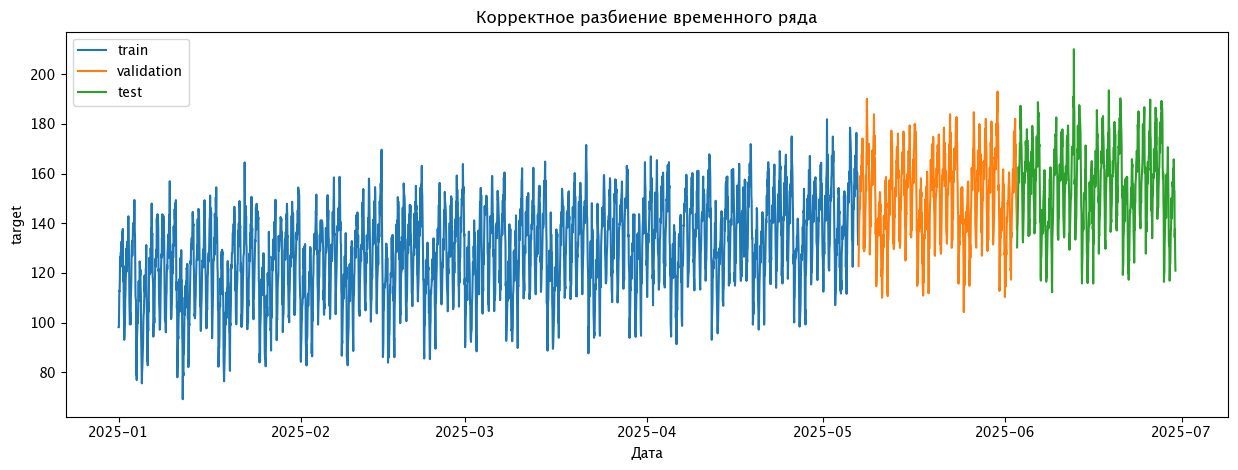

In [41]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректное разбиение временного ряда")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.legend()
plt.show()

Важно отметить, что вместо классического случайного разбиения (random split), которое перемешивает наблюдения в хаотичном порядке, необходимо выполнить временное разбиение (temporal split), сохраняющее естественную временную последовательность данных.

In [21]:
df_vith_signs = df.copy()

df_vith_signs[f'lag_1'] = df_vith_signs['target'].shift(1)
df_vith_signs[f'lag_7'] = df_vith_signs['target'].shift(7)
df_vith_signs[f'lag_14'] = df_vith_signs['target'].shift(14)
    
df_vith_signs['rolling_mean_7'] = df_vith_signs['target'].shift(1).rolling(7).mean()
df_vith_signs['rolling_std_7'] = df_vith_signs['target'].shift(1).rolling(7).std()
    
df_vith_signs['dayofweek'] = df_vith_signs['date'].dt.dayofweek
df_vith_signs['hour'] = df_vith_signs['date'].dt.hour
df_vith_signs = df_vith_signs.dropna()
df_vith_signs.head()

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
14,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14
15,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15
16,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16
17,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17
18,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18


In [32]:
results = []

train_feat = df_vith_signs[df_vith_signs['date'] <= train_df['date'].max()]
val_feat = df_vith_signs[(df_vith_signs['date'] > train_df['date'].max()) & (df_vith_signs['date'] <= val_df['date'].max())]
test_feat = df_vith_signs[df_vith_signs['date'] > val_df['date'].max()]

scaler = StandardScaler()
X_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'hour']

train_feat_scaled = train_feat.copy()
train_feat_scaled[X_cols] = scaler.fit_transform(train_feat[X_cols])

val_feat_scaled = val_feat.copy()
val_feat_scaled[X_cols] = scaler.transform(val_feat[X_cols])

test_feat_scaled = test_feat.copy()
test_feat_scaled[X_cols] = scaler.transform(test_feat[X_cols])

In [131]:
def get_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape': mean_absolute_percentage_error(y_true, y_pred) *100
    }

In [132]:
results = []

B1 = get_metrics(val_feat['target'], val_feat['lag_1'])
results.append({'id': 'B1', **B1})

B2 = get_metrics(val_feat['target'], val_feat['rolling_mean_7'])
results.append({'id': 'B2', **B2})

model_b3 = Ridge()
model_b3.fit(train_feat_scaled[X_cols], train_feat_scaled['target'])
y_pred_b3 = model_b3.predict(val_feat_scaled[X_cols])
B3 = get_metrics(val_feat_scaled['target'], y_pred_b3)
results.append({'id': 'B3', **B3})

pd.DataFrame(results)

,id,mae,rmse,mape
0,B1,6.444815,8.201023,4.397922
1,B2,12.702013,15.217645,8.816864
2,B3,6.360191,7.886871,4.282035


In [ ]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32) 
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 24  # Глубина контекста: модель смотрит на сутки в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        
        y.append(series_2d[i + window_size, 0])         
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (3000, 24, 1) y_train: (3000,)
X_val  : (624, 24, 1) y_val  : (624,)
X_test : (624, 24, 1) y_test : (624,)


Форма одного окна: (24, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -1.7966986


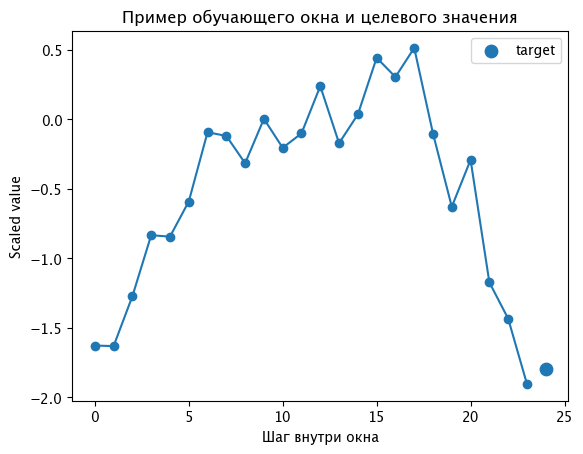

In [85]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [86]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 24, 1])
Batch y: torch.Size([64])


In [87]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [145]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device=device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)
        
    torch.save(model.state_dict(), 'artifacts/best_gru.pt')
    print(best_val_loss)

    return history

In [146]:
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.6670 | val_loss=0.5849
Epoch 02 | train_loss=0.2703 | val_loss=0.2748
Epoch 03 | train_loss=0.1614 | val_loss=0.2282
Epoch 04 | train_loss=0.1514 | val_loss=0.2340
Epoch 05 | train_loss=0.1514 | val_loss=0.1700
Epoch 06 | train_loss=0.1478 | val_loss=0.2161
Epoch 07 | train_loss=0.1468 | val_loss=0.1993
Epoch 08 | train_loss=0.1442 | val_loss=0.2836
Epoch 09 | train_loss=0.1440 | val_loss=0.1792
Epoch 10 | train_loss=0.1411 | val_loss=0.2202
Epoch 11 | train_loss=0.1380 | val_loss=0.2109
Epoch 12 | train_loss=0.1308 | val_loss=0.1899
Epoch 13 | train_loss=0.1192 | val_loss=0.1996
Epoch 14 | train_loss=0.1112 | val_loss=0.2113
Epoch 15 | train_loss=0.1096 | val_loss=0.2011
Epoch 16 | train_loss=0.1055 | val_loss=0.2476
Epoch 17 | train_loss=0.1042 | val_loss=0.1731
Epoch 18 | train_loss=0.1037 | val_loss=0.1834
Epoch 19 | train_loss=0.1015 | val_loss=0.1778
Epoch 20 | train_loss=0.1045 | val_loss=0.1576
Epoch 21 | train_loss=0.1013 | val_loss=0

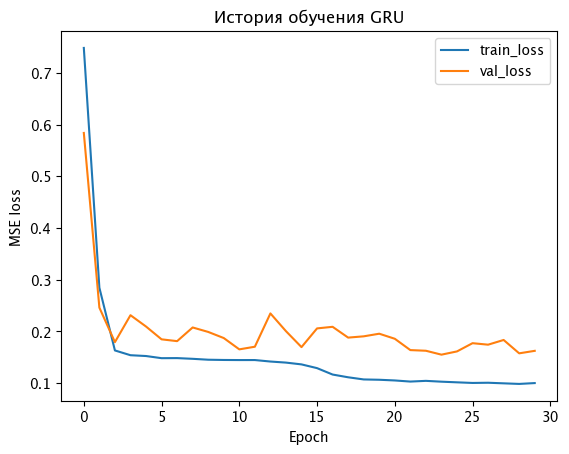

In [90]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

In [133]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) *100
    return {"mae": mae, "rmse": rmse, "mape": mape}

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)


val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

results.append({'id': 'R1', **regression_metrics(val_true, gru_val_pred)})
val_res = pd.DataFrame(results)
val_res

,id,mae,rmse,mape
0,B1,6.444815,8.201023,4.397922
1,B2,12.702013,15.217645,8.816864
2,B3,6.360191,7.886871,4.282035
3,R1,6.327926,8.014194,4.192569


In [139]:
val_results_df = pd.DataFrame(results)
best_model_id = val_results_df.loc[val_results_df['mae'].idxmin(), 'id']
best_val_mae_score = val_results_df['mae'].min()
print(best_model_id, best_val_mae_score)
best_val_mae = val_results_df['mae'].min()
best_val_rmse = val_results_df['rmse'].min()
best_val_mape = val_results_df['mape'].min()

R1 6.327925682067871


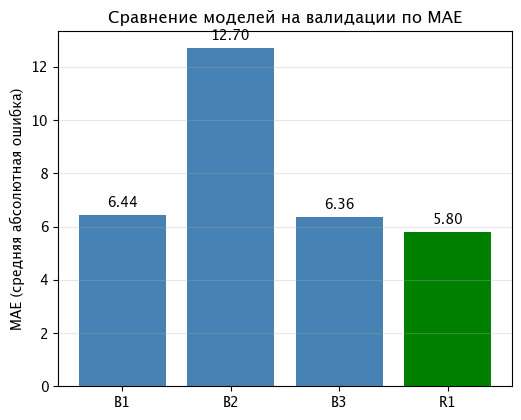

In [97]:
plt.figure(figsize=(10, 8))

# График MAE
plt.subplot(2, 2, 1)
ids = val_results_df['id'].values
maes = val_results_df['mae'].values
colors = ['green' if id == best_model_id else 'steelblue' for id in ids]
plt.bar(ids, maes, color=colors)
plt.ylabel('MAE (средняя абсолютная ошибка)')
plt.title('Сравнение моделей на валидации по MAE')
for i, v in enumerate(maes):
    plt.text(i, v + 0.3, f'{v:.2f}', ha='center')
plt.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

In [99]:
model = gru_model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [102]:

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

test_true = inverse_scale(gru_test_true_scaled, scaler)

gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)

# Вычисляем финальные метрики
test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
)

test_metrics

,model,mae,rmse,mape
0,GRU,6.576505,8.313167,4.247937


Лучшая модель на test: GRU


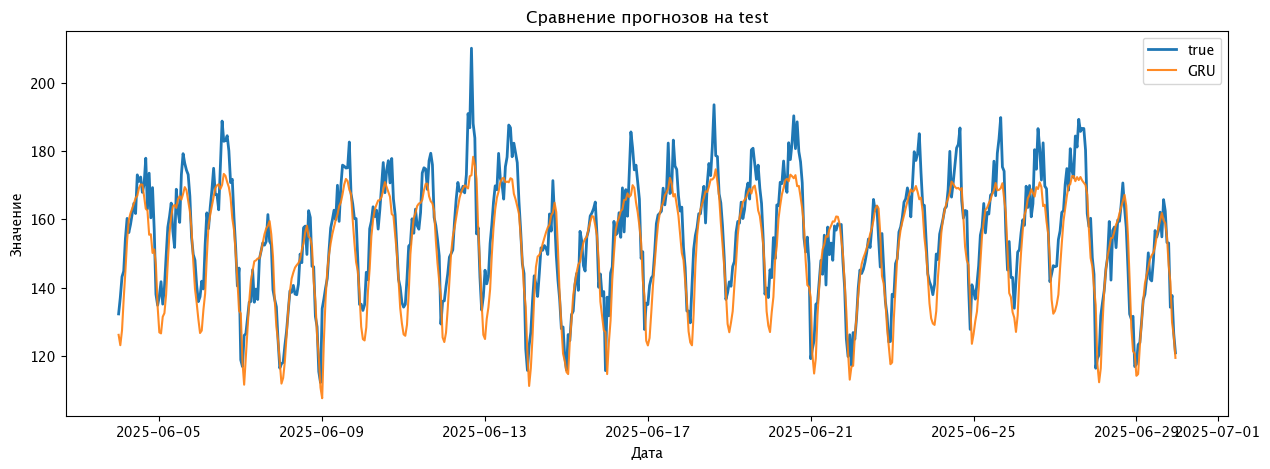

In [105]:
best_model_name = test_metrics.iloc[0]["model"]
print("Лучшая модель на test:", best_model_name)

plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)

# Строим полные прогнозы всех трех подходов
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

In [ ]:
results['B1', ]


[{'id': 'B1',
  'mae': 6.444814814814815,
  'rmse': np.float64(8.20102295260389),
  'mape': 0.0439792166354992},
 {'id': 'B2',
  'mae': 12.702012786596118,
  'rmse': np.float64(15.217644526713752),
  'mape': 0.0881686403093607},
 {'id': 'B3',
  'mae': 6.360190695449111,
  'rmse': np.float64(7.886870745106805),
  'mape': 0.042820346731064676},
 {'id': 'R1',
  'mae': 5.798508644104004,
  'rmse': 7.473779748428993,
  'mape': np.float32(3.900771)}]

In [142]:
config = {
    'model_type': 'GRU',
    'window_size': 24,
    'hidden_size': 64,
    'num_layers': 2,
    'learning_rate': 0.001,
    'batch_size': batch_size,
    'n_epochs': 30,
    'best_epoch': 27,
    'best_val_mae': float(best_val_mae),
    'best_val_rmse': float(best_val_rmse),
    'best_val_mape': float(best_val_mape),
    'test_mae': float(test_metrics.loc[0, 'mae']),
    'test_rmse': float(test_metrics.loc[0, 'rmse']),
    'test_mape': float(test_metrics.loc[0, 'mape']),
    'seed': RANDOM_SEED,
    'device': str(device)
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

In [144]:
runs_records = []

for _, row in val_results_df.iterrows():
    record = {
        'experiment_id': row['id'],
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': RANDOM_SEED,
        'split_summary': f'обучение:{len(train_df)}, валидация:{len(val_df)}, тест:{len(test_df)}',
        'window_size': window_size if row['id'] == 'R1' else None,
        'horizon': 1,
        'model_summary': 'Наивный прогноз' if row['id'] == 'B1' 
                        else ('Скользящее среднее' if row['id'] == 'B2'
                              else ('Ridge регрессия' if row['id'] == 'B3'
                                    else f'GRU (окно={window_size})')),
        'features_summary': 'lag_1' if row['id'] == 'B1'
                           else ('rolling_mean_7' if row['id'] == 'B2'
                                 else ('лаги + статистики + календарь' if row['id'] == 'B3'
                                       else 'только target (окна)')),
        'scaler': 'Нет' if row['id'] in ['B1', 'B2'] else 'StandardScaler',
        'optimizer': 'Adam' if row['id'] == 'R1' else None,
        'lr': 1e-4 if row['id'] == 'R1' else None,
        'epochs_trained': 27 if row['id'] == 'R1' else None,
        'best_val_mae': row['mae'],
        'best_val_rmse': row['rmse'],
        'best_val_mape': row['mape'],
        'test_mae': test_metrics['mae'] if row['id'] == best_model_id else None,
        'test_rmse': test_metrics['rmse'] if row['id'] == best_model_id else None,
        'test_mape': test_metrics['mape'] if row['id'] == best_model_id else None,
        'notes': 'Baseline' if row['id'] in ['B1', 'B2', 'B3'] else 'Лучшая модель'
    }
    runs_records.append(record)

runs_df = pd.DataFrame(runs_records)
runs_df.to_csv('artifacts/runs.csv', index=False)